# **Final Project**
## **Sales & Marketing Customer Churn Prediction**

### **Dataset Description**

This dataset contains customer information related to sales, marketing,
purchases, subscriptions, customer satisfaction, and customer behavior.

The dataset contains approximately 15,000 records and 30 columns.

Each row represents one customer, while the columns contain information
about the customer's characteristics, activity, purchases, satisfaction,
and subscription behavior.

The main goal of this project is to predict whether a customer will leave
the service or continue using it.

The target column is `churn`.

- `churn = 0` → The customer stayed with the service.
- `churn = 1` → The customer left the service.


> ## **Problem Type:**
> * **Type:** Supervised Learning
> * **Task:** Binary Classification
> * **Reason:** The target variable (`churn`) is discrete and categorical, containing only two distinct classes (`0` and `1`). The goal is to predict which category a customer belongs to, rather than predicting a continuous numerical value (which would require Regression).
>
>

In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv('/content/Sales - Marketing customer dataset.csv')
display(df.head())

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [ ]:
df.head(2)

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0


In [ ]:
print(df.isnull().sum())

customer_id                      0
gender                         738
age                           1200
country                          0
city                             0
signup_date                      0
last_purchase_date               0
acquisition_channel              0
device_type                      0
subscription_type                0
is_premium_user                  0
total_visits                     0
avg_session_time                 0
pages_per_session                0
email_open_rate                  0
email_click_rate                 0
total_spent                   1050
avg_order_value                  0
discount_used                    0
coupon_code                   6133
support_tickets                  0
refund_requested                 0
delivery_delay_days              0
payment_method                   0
satisfaction_score             702
nps_score                        0
marketing_spend_per_user         0
lifetime_value                   0
last_3_month_purchas

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  str    
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  str    
 4   city                        15000 non-null  str    
 5   signup_date                 15000 non-null  str    
 6   last_purchase_date          15000 non-null  str    
 7   acquisition_channel         15000 non-null  str    
 8   device_type                 15000 non-null  str    
 9   subscription_type           15000 non-null  str    
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           15000 non-null

In [ ]:
# 1. Clean 'gender' using the mode (most frequent value) safely
if 'gender' in df.columns:
    gender_mode = df['gender'].mode()
    if not gender_mode.empty:
        # Use iloc[0] to safely fetch the actual value regardless of index labels
        df['gender'] = df['gender'].fillna(gender_mode.iloc[0])
        print(" Gender missing values filled successfully.")

# 2. Clean numeric features ('age', 'satisfaction_score', 'total_spent')
# using the Target-Guided Mean to preserve the relationship with 'churn' and maximize model accuracy
target_guided_cols = ['age', 'satisfaction_score', 'total_spent']

for col in target_guided_cols:
    if col in df.columns and 'churn' in df.columns:
        # Fill missing values with the mean of the respective churn group (0 or 1)
        df[col] = df[col].fillna(df.groupby('churn')[col].transform('mean'))
        print(f" {col} cleaned using Target-Guided Mean for high accuracy.")

print("\n All selected columns are cleanly processed and optimized for the target!")

 Gender missing values filled successfully.
 age cleaned using Target-Guided Mean for high accuracy.
 satisfaction_score cleaned using Target-Guided Mean for high accuracy.
 total_spent cleaned using Target-Guided Mean for high accuracy.

 All selected columns are cleanly processed and optimized for the target!


In [ ]:
print(df['gender'].value_counts())

gender
Male      7582
Female    6686
Other      732
Name: count, dtype: int64


In [ ]:
# 1. Handle 'gender' categorical column using get_dummies with drop_first=True
# This ensures binary categories become a single clean column (e.g., gender_Male) avoiding 'other' or NaN issues
if 'gender' in df.columns:
    # Fill missing values with the mode safely first
    mode_val = df['gender'].mode()
    if not mode_val.empty:
        df['gender'] = df['gender'].fillna(mode_val.iloc[0])

    # Apply dummies
    df = pd.get_dummies(df, columns=['gender'], drop_first=True, dtype=float)
    print(" 'gender' successfully converted to a single dummy column.")

print(" Current shape after dummies:", df.shape)

 'gender' successfully converted to a single dummy column.
 Current shape after dummies: (15000, 31)


In [ ]:
df.head()

,customer_id,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,...,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn,gender_Male,gender_Other
0,10001,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,1,...,3,UPI,3.0,10,27.56,915.310827,14,0,1.0,0.0
1,10002,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,0,...,3,BKash,3.0,7,15.15,2079.960938,11,0,1.0,0.0
2,10003,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,1,...,2,UPI,5.0,6,13.51,1379.150885,9,0,0.0,0.0
3,10004,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,1,...,2,PayPal,4.0,6,25.65,774.652684,7,0,0.0,0.0
4,10005,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,0,...,4,BKash,3.0,1,12.39,87.680409,11,0,1.0,0.0


In [ ]:
# List of unneeded or problematic columns to drop
# customer_id: just an ID, coupon_code: has massive missing values (6133)
# signup_date / last_purchase_date: raw dates that need feature engineering or dropping for now
columns_to_drop = ['customer_id', 'coupon_code', 'signup_date', 'last_purchase_date','lifetime_value']

# Drop the columns safely
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

print(" Unwanted columns dropped successfully.")
print(" Current shape of dataset:", df.shape)

 Unwanted columns dropped successfully.
 Current shape of dataset: (15000, 26)


In [ ]:
df. head(2)

,age,country,city,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,...,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,last_3_month_purchase_freq,churn,gender_Male,gender_Other
0,52.0,India,Berlin,Email,Tablet,Annual,1,7,13.903745,5.415164,...,0,3,UPI,3.0,10,27.56,14,0,1.0,0.0
1,35.0,Germany,Mumbai,Organic,Desktop,Monthly,0,19,5.112528,5.352441,...,0,3,BKash,3.0,7,15.15,11,0,1.0,0.0


In [ ]:
print(df.columns)

Index(['age', 'country', 'city', 'acquisition_channel', 'device_type',
       'subscription_type', 'is_premium_user', 'total_visits',
       'avg_session_time', 'pages_per_session', 'email_open_rate',
       'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used',
       'support_tickets', 'refund_requested', 'delivery_delay_days',
       'payment_method', 'satisfaction_score', 'nps_score',
       'marketing_spend_per_user', 'last_3_month_purchase_freq', 'churn',
       'gender_Male', 'gender_Other'],
      dtype='str')


In [ ]:
print(df[['gender_Male', 'gender_Other']].head())

   gender_Male  gender_Other
0          1.0           0.0
1          1.0           0.0
2          0.0           0.0
3          0.0           0.0
4          1.0           0.0


In [ ]:
df.head()

,age,country,city,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,...,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,last_3_month_purchase_freq,churn,gender_Male,gender_Other
0,52.0,India,Berlin,Email,Tablet,Annual,1,7,13.903745,5.415164,...,0,3,UPI,3.0,10,27.56,14,0,1.0,0.0
1,35.0,Germany,Mumbai,Organic,Desktop,Monthly,0,19,5.112528,5.352441,...,0,3,BKash,3.0,7,15.15,11,0,1.0,0.0
2,27.0,Germany,London,Email,Mobile,Annual,1,18,9.742749,3.594719,...,0,2,UPI,5.0,6,13.51,9,0,0.0,0.0
3,36.0,India,Mumbai,Facebook Ads,Tablet,Annual,1,16,9.642654,2.949531,...,0,2,PayPal,4.0,6,25.65,7,0,0.0,0.0
4,29.0,USA,Hamburg,Referral,Mobile,Monthly,0,12,7.791291,2.405539,...,1,4,BKash,3.0,1,12.39,11,0,1.0,0.0


In [ ]:
print(df['acquisition_channel'].unique())
print(df['device_type'].unique())
print(df['subscription_type'].unique())

<ArrowStringArray>
['Email', 'Organic', 'Facebook Ads', 'Referral', 'Google Ads']
Length: 5, dtype: str
<ArrowStringArray>
['Tablet', 'Desktop', 'Mobile']
Length: 3, dtype: str
<ArrowStringArray>
['Annual', 'Monthly']
Length: 2, dtype: str


In [ ]:

df = pd.get_dummies(df, columns=['acquisition_channel'], drop_first=True, dtype=int)
print("Done with acquisition_channel! Current columns count:", df.shape[1])


df = pd.get_dummies(df, columns=['device_type'], drop_first=True, dtype=int)

print("Done with device_type! Current columns count:", df.shape[1])

Done with acquisition_channel! Current columns count: 29
Done with device_type! Current columns count: 30


In [ ]:
df.head(2)

,age,country,city,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,...,last_3_month_purchase_freq,churn,gender_Male,gender_Other,acquisition_channel_Facebook Ads,acquisition_channel_Google Ads,acquisition_channel_Organic,acquisition_channel_Referral,device_type_Mobile,device_type_Tablet
0,52.0,India,Berlin,Annual,1,7,13.903745,5.415164,0.67,0.26,...,14,0,1.0,0.0,0,0,0,0,0,1
1,35.0,Germany,Mumbai,Monthly,0,19,5.112528,5.352441,0.70,0.37,...,11,0,1.0,0.0,0,0,1,0,0,0


In [ ]:
print(df['country'].value_counts())
print(df['city'].value_counts())

country
Germany       3072
India         3014
Bangladesh    2984
USA           2975
UK            2955
Name: count, dtype: int64
city
London      2236
Mumbai      2184
Dhaka       2178
New York    2135
Delhi       2128
Berlin      2075
Hamburg     2064
Name: count, dtype: int64


In [ ]:
# Drop email-related columns if they exist in the dataframe
email_cols_to_drop = ['email_open_rate', 'email_click_rate']

df = df.drop(columns=[col for col in email_cols_to_drop if col in df.columns])
print(" Email columns dropped successfully! Current shape:", df.shape)

 Email columns dropped successfully! Current shape: (15000, 28)


In [ ]:
import pandas as pd

# List of categorical columns to convert into dummies explicitly
categorical_columns = ['country', 'city', 'device_type', 'subscription_type', 'payment_method', 'acquisition_channel']

for col in categorical_columns:
    if col in df.columns:
        # Fill missing values with mode first to avoid issues
        mode_val = df[col].mode()
        if not mode_val.empty:
            df[col] = df[col].fillna(mode_val.iloc[0])

        # Apply get_dummies with drop_first=True
        df = pd.get_dummies(df, columns=[col], drop_first=True, dtype=float)
        print(f" Successfully created dummies for column: '{col}'")

# Final verification of dataset shape and remaining object columns
print("\n Final dataset shape after dummies:", df.shape)
print(" Remaining object columns count:", len(df.select_dtypes(include=['object']).columns))

 Successfully created dummies for column: 'country'
 Successfully created dummies for column: 'city'
 Successfully created dummies for column: 'subscription_type'
 Successfully created dummies for column: 'payment_method'

 Final dataset shape after dummies: (15000, 39)
 Remaining object columns count: 0


In [ ]:
df.head()

,age,is_premium_user,total_visits,avg_session_time,pages_per_session,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,...,city_Dhaka,city_Hamburg,city_London,city_Mumbai,city_New York,subscription_type_Monthly,payment_method_Card,payment_method_PayPal,payment_method_SEPA,payment_method_UPI
0,52.0,1,7,13.903745,5.415164,559.524958,65.246704,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,35.0,0,19,5.112528,5.352441,356.491344,48.473887,1,5,0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,27.0,1,18,9.742749,3.594719,689.332196,77.815371,0,1,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,36.0,1,16,9.642654,2.949531,445.429636,71.712192,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,29.0,0,12,7.791291,2.405539,686.286022,44.990246,1,2,1,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 39 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               15000 non-null  float64
 1   is_premium_user                   15000 non-null  int64  
 2   total_visits                      15000 non-null  int64  
 3   avg_session_time                  15000 non-null  float64
 4   pages_per_session                 15000 non-null  float64
 5   total_spent                       15000 non-null  float64
 6   avg_order_value                   15000 non-null  float64
 7   discount_used                     15000 non-null  int64  
 8   support_tickets                   15000 non-null  int64  
 9   refund_requested                  15000 non-null  int64  
 10  delivery_delay_days               15000 non-null  int64  
 11  satisfaction_score                15000 non-null  float64
 12  nps_score      

In [ ]:
### Step: Checking Correlations with the Target Variable (Churn)

#What: We calculated the statistical correlation coefficient between the target variable (`churn`) and all other numerical features in the dataset, then sorted them in descending order.
#Why: This step helps us identify which features have the strongest linear relationship with customer churn. Positive values indicate features that increase the likelihood of churn, while negative values indicate features that reduce it (helping with feature selection).
#How:We used the `.corr()` function to build a correlation matrix, isolated the `churn` column, and used `.sort_values(ascending=False)` to rank the relationships from highest to lowest.

#Calculate the correlation of all numerical features with the 'churn' column and sort them descending
correlation_with_churn = df.corr()['churn'].sort_values(ascending=False)
# Display the correlation results
print(correlation_with_churn)

churn                               1.000000
support_tickets                     0.127910
gender_Other                        0.019637
total_visits                        0.013212
avg_session_time                    0.012198
city_Hamburg                        0.011711
device_type_Mobile                  0.009998
country_India                       0.008433
acquisition_channel_Organic         0.007801
country_UK                          0.006652
acquisition_channel_Referral        0.006265
subscription_type_Monthly           0.006135
pages_per_session                   0.005871
nps_score                           0.005749
age                                 0.004703
city_Delhi                          0.004239
payment_method_SEPA                 0.003497
delivery_delay_days                 0.001603
last_3_month_purchase_freq          0.001590
country_USA                         0.001499
payment_method_PayPal               0.000756
city_Mumbai                         0.000741
discount_u

In [ ]:
### Step: Feature Scaling for Numerical Variables

#What: We applied Feature Scaling (Standardization) to key numerical columns with varying ranges (such as `total_visits`, `avg_session_time`, `pages_per_session`, `total_spent`, and `avg_order_value`).
#Why:Features with larger numerical scales (like total spent amounts) can disproportionately dominate the objective function of machine learning models compared to smaller-scaled features (like page views). Scaling ensures that all features contribute equally to the model.
#How: We used `StandardScaler` from the `scikit-learn` library to center the data around a mean of `0` with a standard deviation of `1`.
from sklearn.preprocessing import StandardScaler

# Define the numerical columns that require scaling
scaling_columns = ['total_visits', 'avg_session_time', 'pages_per_session', 'total_spent', 'avg_order_value']

# Initialize the StandardScaler tool
scaler = StandardScaler()

# Fit and transform the selected columns in the DataFrame
df[scaling_columns] = scaler.fit_transform(df[scaling_columns])

# Display a preview of the scaled columns to verify the results
print(df[scaling_columns].head())

   total_visits  avg_session_time  pages_per_session  total_spent  \
0     -2.055435          1.966618           0.954363     0.076166   
1      1.027358         -0.972213           0.911977    -0.374311   
2      0.770458          0.575632          -0.275837     0.364174   
3      0.256660          0.542171          -0.711834    -0.176981   
4     -0.770938         -0.076725          -1.079447     0.357415   

   avg_order_value  
0         0.208759  
1        -0.469057  
2         0.716679  
3         0.470040  
4        -0.609837  


In [ ]:
#Task 3: Data Distribution and Relationships

In [ ]:
numericCols = [
    'age',
    'total_visits',
    'avg_session_time',
    'pages_per_session',
    'total_spent',
    'avg_order_value',
    'support_tickets',
    'delivery_delay_days',
    'satisfaction_score',
    'nps_score',
    'marketing_spend_per_user',
    'last_3_month_purchase_freq'
]

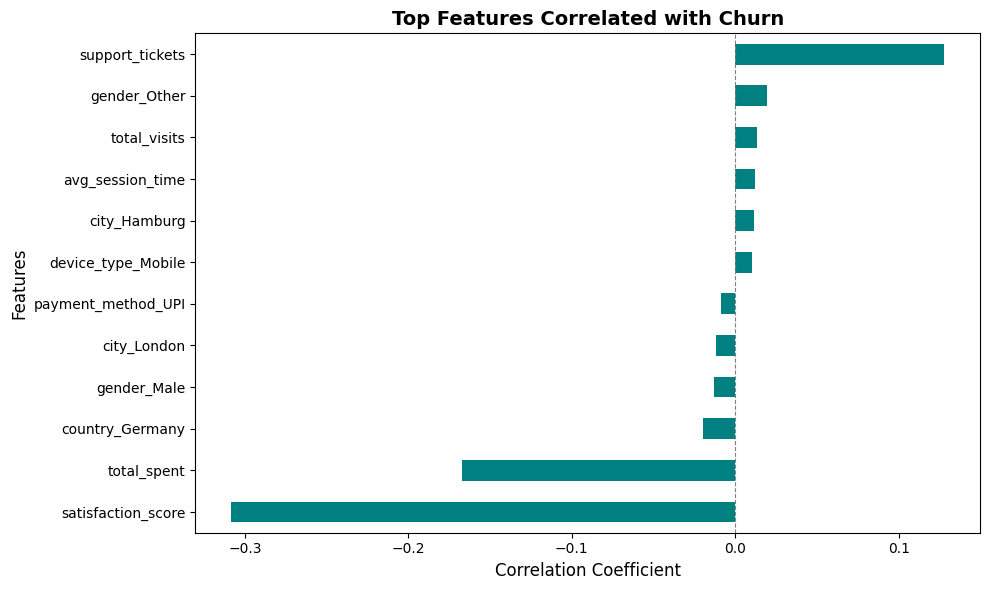

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# حساب الارتباط مع عمود الـ churn وترتيبهم تنازلياً حسب القيمة المطلقة (الأقوى تأثير بغض النظر عن الإشارة)
plt.figure(figsize=(10, 6))
churn_corr = df.select_dtypes(include=['number']).corr()['churn'].drop('churn')

# اختيار أقوى 12 متغير تأثيراً فقط لتجنب الزحمة
top_corr = churn_corr.abs().nlargest(12).index
top_corr_values = churn_corr[top_corr].sort_values()

# الرسم البياني
top_corr_values.plot(kind='barh', color='teal')
plt.title('Top Features Correlated with Churn', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

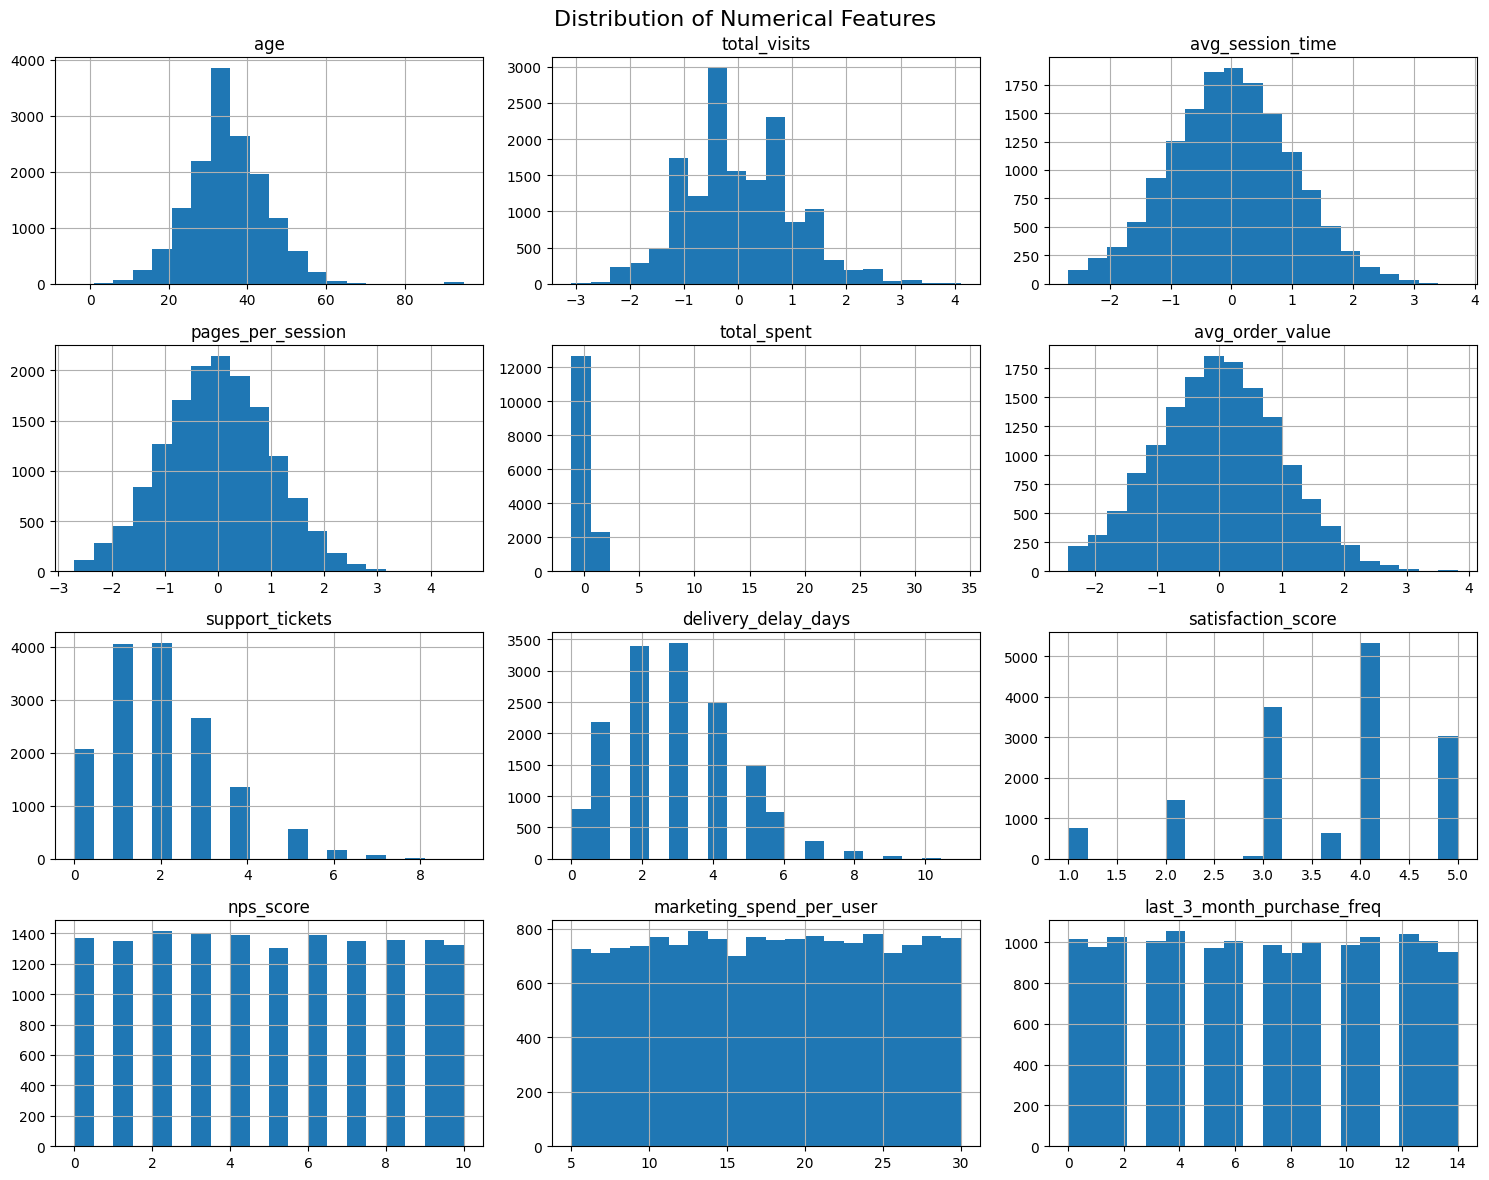

In [ ]:
df[numericCols].hist(figsize=(15, 12), bins=20)

plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

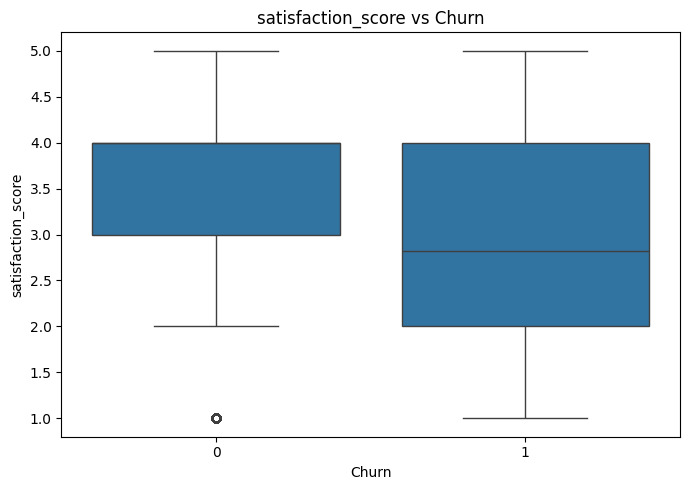

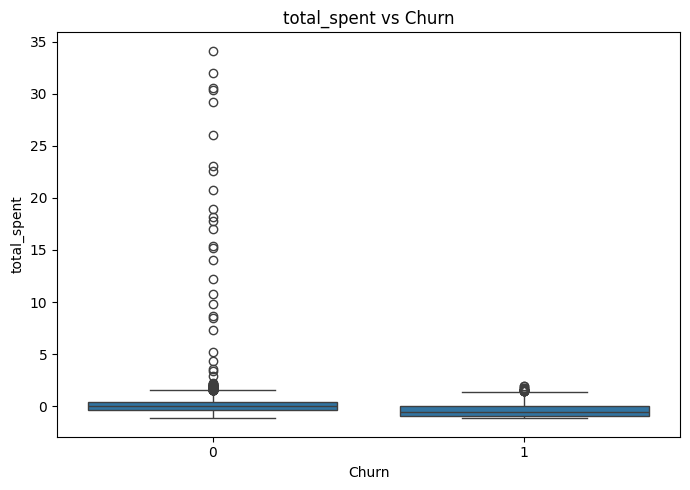

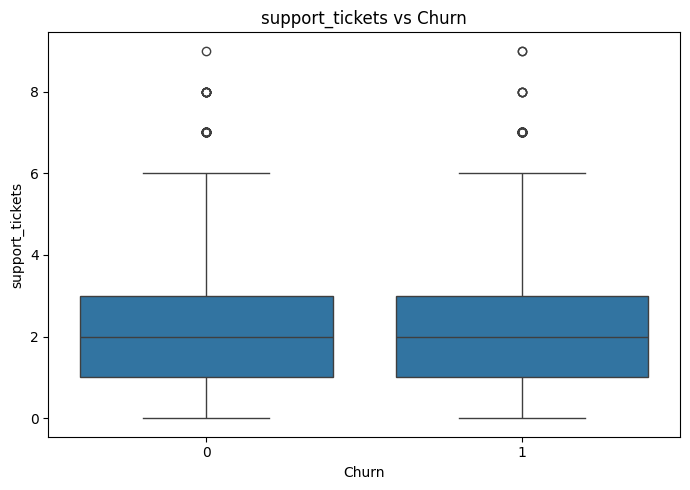

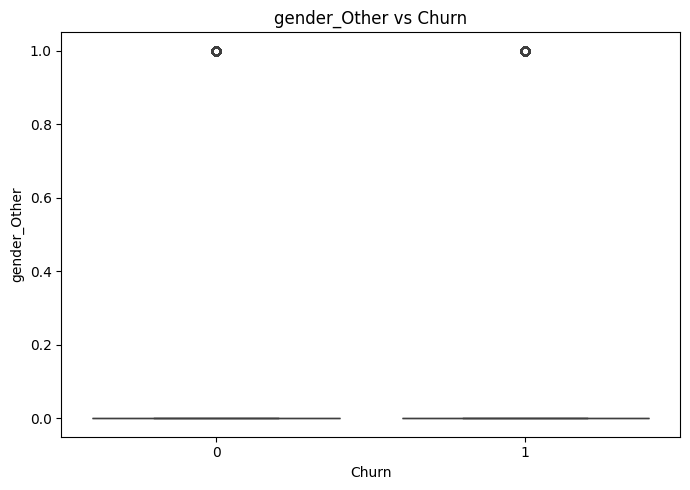

In [ ]:
# Calculate correlation with churn
correlation = df.corr(numeric_only=True)['churn'].sort_values(ascending=False)

# Select the strongest numerical features related to churn
top_features = correlation.abs().sort_values(ascending=False).index[1:5]

for feature in top_features:
    plt.figure(figsize=(7, 5))

    sns.boxplot(x='churn', y=feature, data=df)

    plt.title(f"{feature} vs Churn")
    plt.xlabel("Churn")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

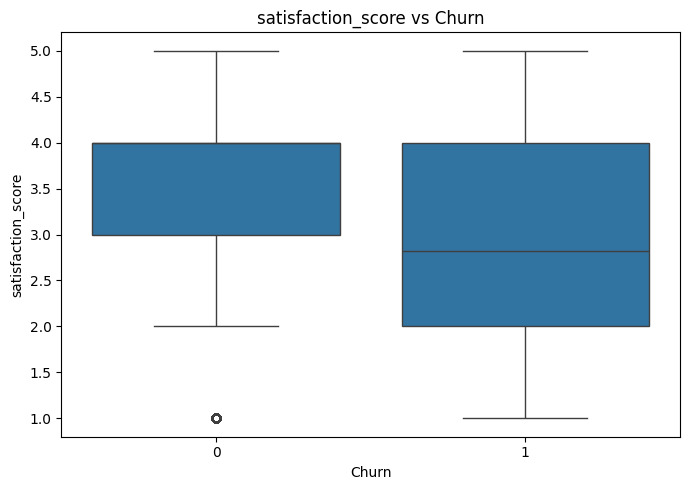

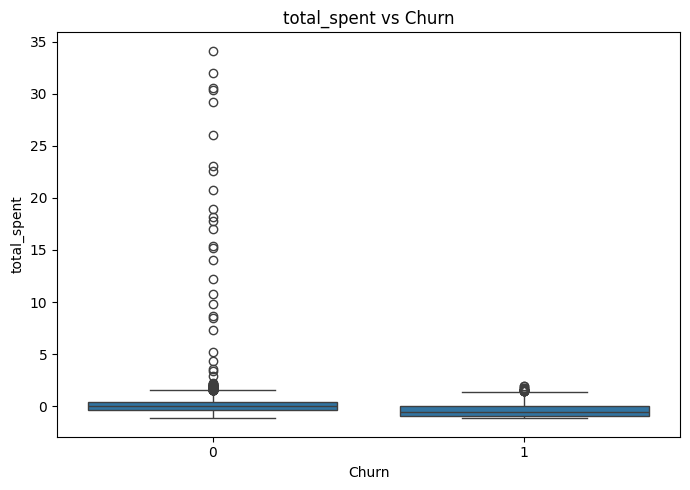

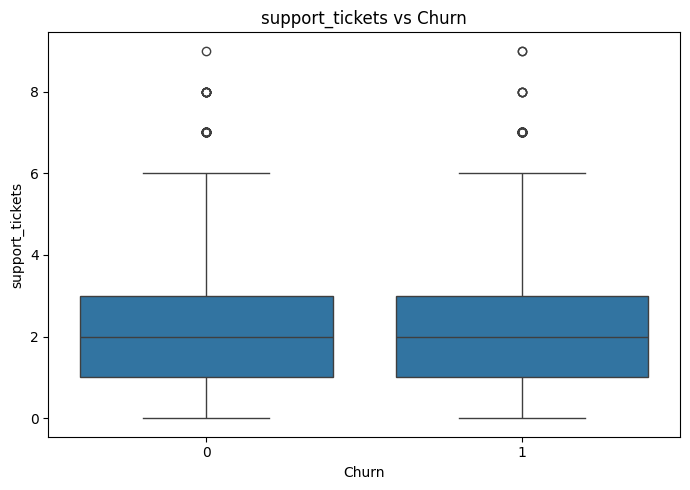

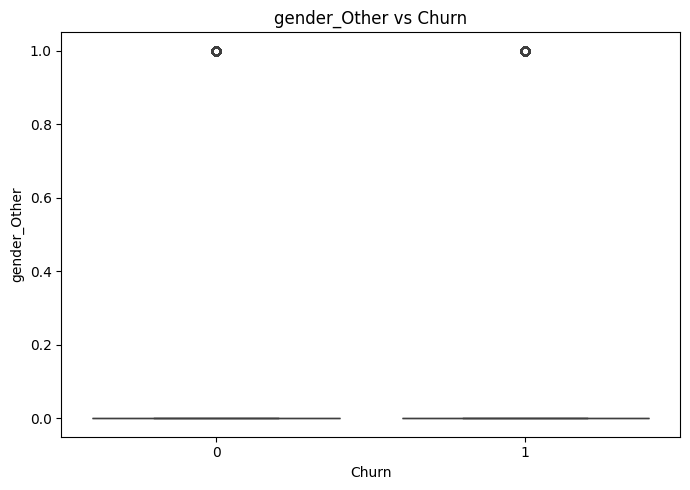

In [ ]:
# Select the strongest numerical correlations with churn
top_features = correlation.abs().sort_values(ascending=False).index[1:5]

for feature in top_features:
    plt.figure(figsize=(7, 5))

    sns.boxplot(x='churn', y=feature, data=df)

    plt.title(f"{feature} vs Churn")
    plt.xlabel("Churn")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

In [ ]:
# Task 4: Baseline Model

In [ ]:

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

baseline1 = DummyClassifier(strategy="most_frequent")
baseline1.fit(X_train, y_train)

y_pred1 = baseline1.predict(X_test)

print("Dummy Classifier Results")
print("Accuracy:", accuracy_score(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1,zero_division=0))
print("Recall:", recall_score(y_test, y_pred1,zero_division=0))
print("F1-score:", f1_score(y_test, y_pred1,zero_division=0))

Dummy Classifier Results
Accuracy: 0.852
Precision: 0.0
Recall: 0.0
F1-score: 0.0


In [ ]:

baseline2 = LogisticRegression(max_iter=5000,solver='saga',random_state=42)
baseline2.fit(X_train, y_train)

y_pred2 = baseline2.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2))
print("Recall:", recall_score(y_test, y_pred2))
print("F1-score:", f1_score(y_test, y_pred2))

Logistic Regression Results
Accuracy: 0.856
Precision: 0.5344827586206896
Recall: 0.20945945945945946
F1-score: 0.30097087378640774


In [ ]:
from sklearn.ensemble import RandomForestClassifier

baseline3 = RandomForestClassifier(random_state=42)
baseline3.fit(X_train, y_train)

y_pred3 = baseline3.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred3))
print("Precision:", precision_score(y_test, y_pred3, zero_division=0))
print("Recall:", recall_score(y_test, y_pred3, zero_division=0))
print("F1-score:", f1_score(y_test, y_pred3, zero_division=0))

Random Forest Results
Accuracy: 0.8673333333333333
Precision: 0.583941605839416
Recall: 0.36036036036036034
F1-score: 0.4456824512534819


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN Results")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_knn, zero_division=0))
print("F1-score:", f1_score(y_test, y_pred_knn, zero_division=0))

KNN Results
Accuracy: 0.8473333333333334
Precision: 0.4
Recall: 0.06306306306306306
F1-score: 0.10894941634241245


In [ ]:
print(y_train.value_counts())

churn
0    10146
1     1854
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# Ensure data is clean and categorical columns are converted
df = pd.get_dummies(df)
df = df.dropna()

# Create subsets for 1%, 10%, and 100% of the data, keeping class distribution balanced
df_1pct, _ = train_test_split(df, train_size=0.01, random_state=42, stratify=df['churn'])
df_10pct, _ = train_test_split(df, train_size=0.10, random_state=42, stratify=df['churn'])
df_100pct = df.copy()  # Full dataset

# Store them in a dictionary for easy looping
datasets = {
    "1% Data": df_1pct,
    "10% Data": df_10pct,
    "100% Data": df_100pct
}

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score
import time

results = []

for name, data in datasets.items():
    X = data.drop(columns=['churn'])
    y = data['churn']

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42)
    }

    for model_name, model in models.items():
        start_time = time.time()
        model.fit(X_tr, y_tr)
        exec_time = time.time() - start_time

        preds = model.predict(X_te)

        prec = precision_score(y_te, preds, zero_division=0)
        rec = recall_score(y_te, preds, zero_division=0)
        f1 = f1_score(y_te, preds, zero_division=0)
        f_beta = fbeta_score(y_te, preds, beta=1.0, zero_division=0)

        results.append({
            "Dataset": name,
            "Model": model_name,
            "Precision": prec,
            "Recall": rec,
            "F1_Score": f1,
            "F_Beta": f_beta,
            "Time (s)": round(exec_time, 4)
        })

# Convert results into a clean DataFrame and display it nicely
results_df = pd.DataFrame(results)
display(results_df)

,Dataset,Model,Precision,Recall,F1_Score,F_Beta,Time (s)
0,1% Data,Logistic Regression,0.000000,0.000000,0.000000,0.000000,0.0387
1,1% Data,Random Forest,0.000000,0.000000,0.000000,0.000000,0.0718
2,10% Data,Logistic Regression,0.409091,0.195652,0.264706,0.264706,0.0664
3,10% Data,Random Forest,0.500000,0.173913,0.258065,0.258065,0.1475
4,100% Data,Logistic Regression,0.539394,0.193478,0.284800,0.284800,0.2326
5,100% Data,Random Forest,0.616327,0.328261,0.428369,0.428369,1.0736


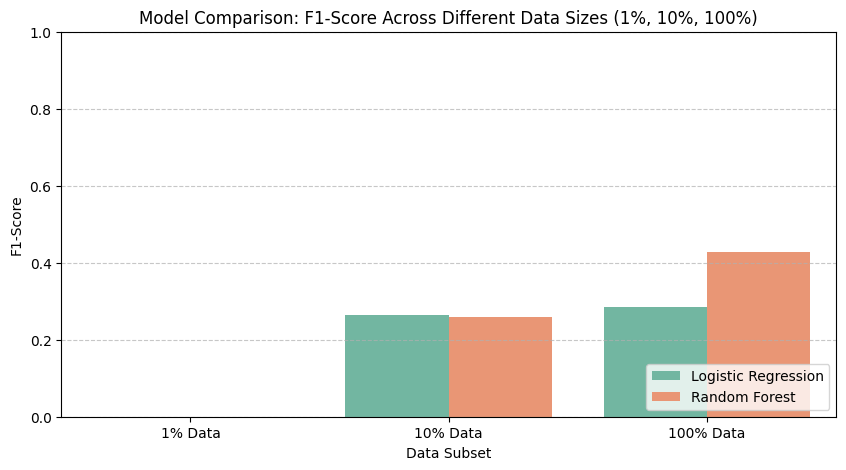

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting F1-Score comparison across datasets and models
plt.figure(figsize=(10, 5))
sns.barplot(x="Dataset", y="F1_Score", hue="Model", data=results_df, palette="Set2")

plt.title("Model Comparison: F1-Score Across Different Data Sizes (1%, 10%, 100%)")
plt.ylabel("F1-Score")
plt.xlabel("Data Subset")
plt.ylim(0, 1.0)
plt.legend(loc="lower right")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import ParameterGrid, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm  # 👈 التغيير الأساسي: استخدام tqdm القياسية بدلاً من notebook

# 1. تحديد شبكة المعايير (144 تركيبة)
param_grid = {
    'n_estimators': [50, 100, 45, 75],
    'max_depth': [5, 10, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = list(ParameterGrid(param_grid))
total_models = len(grid)

best_score_f1 = 0
best_params_f1 = None

print("🚀 جاري بدء البحث مع شريط النسبة المئوية المباشر...")

# 2. شريط النسبة المئوية النصي الشامل
for params in tqdm(grid, desc="مؤشر الإنجاز", bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{percentage:3.0f}%]'):
    rf = RandomForestClassifier(**params, class_weight='balanced', random_state=42, n_jobs=-1)

    # تقييم سريع بالـ F1-Score عبر 5-Fold Cross Validation
    scores = cross_val_score(rf, X_tr, y_tr, cv=5, scoring='f1', n_jobs=-1)
    mean_score = np.mean(scores)

    if mean_score > best_score_f1:
        best_score_f1 = mean_score
        best_params_f1 = params

print("\n🎉 اكتمل البحث بنجاح 100%!")

# 3. تدريب النموذج الأفضل
best_rf_f1 = RandomForestClassifier(**best_params_f1, class_weight='balanced', random_state=42, n_jobs=-1)
best_rf_f1.fit(X_tr, y_tr)

# 4. التنبؤ وعرض جميع النتائج بالمائة (%)
test_pred = best_rf_f1.predict(X_te)

accuracy = accuracy_score(y_te, test_pred)
precision = precision_score(y_te, test_pred)
recall = recall_score(y_te, test_pred)
f1 = f1_score(y_te, test_pred)

print("\n=== Best Hyperparameters Found ===")
print(best_params_f1)
print(f"Best CV F1-Score: {best_score_f1 * 100:.2f}%  ({best_score_f1:.4f})")

print("\n=== Test Evaluation Metrics (النسب المئوية) ===")
print(f"Accuracy  : {accuracy * 100:.2f}%  ({accuracy:.4f})")
print(f"Precision : {precision * 100:.2f}% ({precision:.4f})")
print(f"Recall    : {recall * 100:.2f}%    ({recall:.4f})")
print(f"F1-score  : {f1 * 100:.2f}%      ({f1:.4f})")

🚀 جاري بدء البحث مع شريط النسبة المئوية المباشر...


مؤشر الإنجاز: 100%|██████████| 144/144 [100%]


🎉 اكتمل البحث بنجاح 100%!

=== Best Hyperparameters Found ===
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Best CV F1-Score: 66.91%  (0.6691)

=== Test Evaluation Metrics (النسب المئوية) ===
Accuracy  : 85.83%  (0.8583)
Precision : 52.00% (0.5200)
Recall    : 99.13%    (0.9913)
F1-score  : 68.21%      (0.6821)


In [ ]:
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV

# 1. تدريب النموذج المبدئي (قبل الـ CV)
base_model = RandomForestClassifier(random_state=42)
base_model.fit(X_train, y_train)

# توقعات النموذج المبدئي
y_train_pred_before = base_model.predict(X_train)
y_test_pred_before = base_model.predict(X_test)

# 2. تطبيق Cross-Validation مع الضبط (بعد الـ CV)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
}

cv_model = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    return_train_score=True,
    n_jobs=-1,
)

cv_model.fit(X_train, y_train)
best_cv_model = cv_model.best_estimator_

# توقعات النموذج الأفضل بعد الـ CV
y_train_pred_after = best_cv_model.predict(X_train)
y_test_pred_after = best_cv_model.predict(X_test)


# 3. دالة حساب المقاييس
def get_metrics(y_true, y_pred):
  return {
      'Accuracy': round(accuracy_score(y_true, y_pred), 4),
      'Precision': round(
          precision_score(y_true, y_pred, average='weighted', zero_division=0),
          4,
      ),
      'Recall': round(
          recall_score(y_true, y_pred, average='weighted', zero_division=0), 4
      ),
      'F1-Score': round(
          f1_score(y_true, y_pred, average='weighted', zero_division=0), 4
      ),
  }


# 4. تجميع وترتيب جدول المقارنة (Before vs After CV)
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Train (Before CV)': list(
        get_metrics(y_train, y_train_pred_before).values()
    ),
    'Test (Before CV)': list(get_metrics(y_test, y_test_pred_before).values()),
    'Train (After CV)': list(
        get_metrics(y_train, y_train_pred_after).values()
    ),
    'Test (After CV)': list(get_metrics(y_test, y_test_pred_after).values()),
}

comparison_df = pd.DataFrame(comparison_data)

# طباعة جدول المقارنة النهائي
print('📊 مقارنة أداء النموذج قبل وبعد الـ Cross-Validation:')
display(comparison_df)

# =========================================================
# 5. الجزء المضاف: حفظ النموذج الأفضل + جدول Task 7 والأعمدة
# =========================================================
model_package = {
    'model': best_cv_model,
    'features': list(X_train.columns),
    'comparison_table': comparison_df,
}

joblib.dump(model_package, 'best_model.pkl')
print(
    "\n✅ تم تصدير 'best_model.pkl' بنجاح! نَزّل هذا الملف واستخدمه في تطبيق"
    ' Streamlit.'
)

📊 مقارنة أداء النموذج قبل وبعد الـ Cross-Validation:


,Metric,Train (Before CV),Test (Before CV),Train (After CV),Test (After CV)
0,Accuracy,1.0,0.8673,0.9998,0.8667
1,Precision,1.0,0.8497,0.9998,0.8508
2,Recall,1.0,0.8673,0.9998,0.8667
3,F1-Score,1.0,0.8538,0.9997,0.8554



✅ تم تصدير 'best_model.pkl' بنجاح! نَزّل هذا الملف واستخدمه في تطبيق Streamlit.
